# RDA maDMP evaluation: all samples in one view

One figure for all samples together, then one figure for each sample, every model side by side.
It reads the evaluation that `pdf-to-rda-dmp-json.ipynb` saved for the run; no model is
called and nothing is re-scored.

**To look at another run:** change `RUN` in the next cell and run all cells. Only samples
with a hand-made reference appear, because only those can be scored.

**How to read it**

| Word | Meaning |
|---|---|
| **found** | reference fields the model got right, out of the fields the person filled in |
| **correct** | fields the model wrote that match the reference, including fields both left empty |
| **hallucinated** | fields the model wrote that are wrong, made up, or filled where the person left them empty |
| **missed** | reference fields the model never got right |
| **precision** | correct / everything the model wrote |
| **recall** | found / fields in the reference |
| **F1** | the balance of the two |


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

if Path.cwd().name == "notebooks":
    import os
    os.chdir(Path.cwd().parent)

RUN    = "v3"                                    # a folder name under data/output/rda/runs/
RESULT = Path("data/output/rda/runs") / RUN / "evaluation_results.xlsx"
CHART  = Path("data/output/rda/runs") / RUN / "evaluation_overview.png"   # per-sample figures go next to it
MODELS = ["llama3.1-8b", "gemma4-e4b", "llama3.3-70b"]

# The repo's palette: model slots 1-3 as in every other notebook, verdicts blue / red / gray
MODEL_COLOUR   = dict(zip(MODELS, ["#2a78d6", "#eb6834", "#1baf7a"]))
VERDICT_COLOUR = {"correct": "#2a78d6", "hallucinated": "#e34948", "missed": "#898781"}
INK, MUTED, SURFACE, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e6e6e2"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "text.color": INK,
    "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED, "axes.edgecolor": "#d8d8d4",
    "axes.titlecolor": INK, "font.size": 10, "axes.titlesize": 11.5, "axes.titleweight": "bold",
    "legend.frameon": False,
})
pd.set_option("display.width", 200)

saved = sorted(p.parent.name for p in Path("data/output/rda/runs").glob("*/evaluation_results.xlsx"))
print(f"run: {RUN}   (runs with a saved evaluation: {', '.join(saved)})")


run: v3   (runs with a saved evaluation: v1, v1-sample14, v2, v2-sample14, v3, v3-sample14, v4-sample14, v5-sample14, v6, v7)


## 1. Scores per sample and model

One row per sample and model, then all samples pooled per model. "All" adds up the counts
across samples before computing the scores, so a sample with many fields weighs more.


In [2]:
details = pd.read_excel(RESULT, sheet_name="details")
if "sample" not in details:                      # runs saved before samples were recorded hold one sample
    details["sample"] = int(next(p.stem.split(".")[0][6:] for p in RESULT.parent.glob("sample*.rda.*.json")))


def score(g):
    correct = int((g.verdict == "Correct").sum())
    halluc = int((g.verdict == "Hallucinated").sum())
    missed = int((g.verdict == "Missed").sum())
    hits = g[(g.verdict == "Correct") & g["reference value"].notna()]
    key = hits["sample"].astype(str) + "|" + hits.field if "sample" in hits else hits.field   # same field in two samples counts twice
    found = int(key.nunique())
    n_ref = found + missed
    p = correct / (correct + halluc) if correct + halluc else 0.0
    r = found / n_ref if n_ref else 0.0
    return pd.Series({"fields in reference": n_ref, "found": found, "correct": correct, "hallucinated": halluc,
                      "missed": missed, "precision": round(p, 3), "recall": round(r, 3),
                      "f1": round(2 * p * r / (p + r), 3) if p + r else 0.0})


models = [m for m in MODELS if m in set(details.model)]
per_sample = details.groupby(["sample", "model"]).apply(score, include_groups=False).reset_index()
pooled = details.groupby("model").apply(score, include_groups=False).reset_index().assign(sample="All")
table = pd.concat([per_sample, pooled], ignore_index=True)
table["sample"] = table["sample"].astype(str)
counts = ["fields in reference", "found", "correct", "hallucinated", "missed"]
table[counts] = table[counts].astype(int)
samples = [str(s) for s in sorted(details["sample"].unique())] + ["All"]
table["order"] = table["sample"].map(samples.index) * 10 + table["model"].map(models.index)
table = table.sort_values("order").drop(columns="order").reset_index(drop=True)
display(table.set_index(["sample", "model"]))


fields in reference  found  correct  hallucinated  missed  precision  recall     f1
sample model                                                                                            
1      llama3.1-8b                    12      1        1            40      11      0.024   0.083  0.038
       gemma4-e4b                     12      1        1            20      11      0.048   0.083  0.061
       llama3.3-70b                   12      0        0            53      12      0.000   0.000  0.000
2      llama3.1-8b                    25      0        0            26      25      0.000   0.000  0.000
       gemma4-e4b                     25      0        0            21      25      0.000   0.000  0.000
       llama3.3-70b                   25      0        0            33      25      0.000   0.000  0.000
3      llama3.1-8b                    13      4        4            31       9      0.114   0.308  0.167
       gemma4-e4b                     13      3        3            29      10      0.094   0.231  0.133
       llama3.3-70b                   13      5        5            39       8      0.114   0.385  0.175
4      llama3.1-8b                    14      1        1            27      13      0.036   0.071  0.048
       gemma4-e4b                     14      2        2            33      12      0.057   0.143  0.082
       llama3.3-70b                   14      4        4            40      10      0.091   0.286  0.138
5      llama3.1-8b                    31      1        1            27      30      0.036   0.032  0.034
       gemma4-e4b                     31      1        1            19      30      0.050   0.032  0.039
       llama3.3-70b                   31      0        0            58      31      0.000   0.000  0.000
6      llama3.1-8b                    11      2        2            21       9      0.087   0.182  0.118
       gemma4-e4b                     11      1        1            16      10      0.059   0.091  0.071
       llama3.3-70b                   11      2        2            27       9      0.069   0.182  0.100
7      llama3.1-8b                     7      0        0            17       7      0.000   0.000  0.000
       gemma4-e4b                      7      2        2            21       5      0.087   0.286  0.133
       llama3.3-70b                    7      5        5            29       2      0.147   0.714  0.244
8      llama3.1-8b                     7      0        0            16       7      0.000   0.000  0.000
       gemma4-e4b                      7      1        1            15       6      0.062   0.143  0.087
       llama3.3-70b                    7      1        1            34       6      0.029   0.143  0.048
9      llama3.1-8b                    35      3        3            38      32      0.073   0.086  0.079
       gemma4-e4b                     35      5        5            39      30      0.114   0.143  0.127
       llama3.3-70b                   35      5        5            45      30      0.100   0.143  0.118
10     llama3.1-8b                    14      0        0            16      14      0.000   0.000  0.000
       gemma4-e4b                     14      1        1            27      13      0.036   0.071  0.048
       llama3.3-70b                   14      1        1            37      13      0.026   0.071  0.038
All    llama3.1-8b                   169     12       12           259     157      0.044   0.071  0.055
       gemma4-e4b                    169     17       17           240     152      0.066   0.101  0.080
       llama3.3-70b                  169     23       23           395     146      0.055   0.136  0.078

## 2. Overview: all samples together

The counts of every sample are added up per model. Left: precision, recall and F1 per
model. Right: what each model did with the fields, as shares of everything judged —
correct (blue), hallucinated (red), missed (gray) — with the counts in the labels.


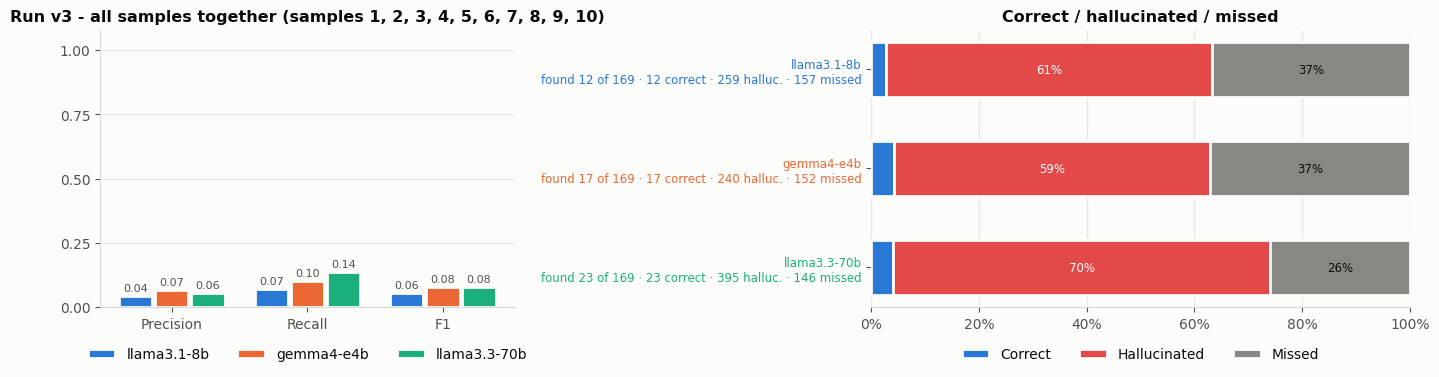

saved -> data\output\rda\runs\v3\evaluation_overview.png


In [3]:
def plot_scores(rows, title, save_to):
    # Left: precision / recall / F1 per model. Right: correct / hallucinated / missed shares.
    rows = rows.set_index("model").reindex([m for m in models if m in set(rows.model)])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3.9), gridspec_kw={"width_ratios": [1, 1.3]})

    shown = ["precision", "recall", "f1"]
    w = 0.8 / len(rows)
    for k, m in enumerate(rows.index):
        xs = [i + (k - (len(rows) - 1) / 2) * w for i in range(len(shown))]
        bars = ax1.bar(xs, [rows.loc[m, s] for s in shown], width=w * 0.92, color=MODEL_COLOUR[m],
                       edgecolor=SURFACE, linewidth=2, label=m)
        ax1.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, color=MUTED)
    ax1.set_xticks(range(len(shown)))
    ax1.set_xticklabels(["Precision", "Recall", "F1"])
    ax1.set_ylim(0, 1.08)
    ax1.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax1.set_title(title)
    ax1.grid(axis="y", color=GRID, linewidth=0.9)
    ax1.set_axisbelow(True)
    ax1.legend(ncol=len(rows), loc="upper center", bbox_to_anchor=(0.5, -0.1))
    for side in ("top", "right"):
        ax1.spines[side].set_visible(False)

    order = rows.iloc[::-1]                                   # first model at the top
    totals = order[["correct", "hallucinated", "missed"]].sum(axis=1).replace(0, 1)
    left = [0.0] * len(order)
    for v in ("correct", "hallucinated", "missed"):
        vals = (order[v] / totals).tolist()
        bars = ax2.barh(range(len(order)), vals, left=left, height=0.55, color=VERDICT_COLOUR[v],
                        edgecolor=SURFACE, linewidth=2, label=v.capitalize())
        for bar, val in zip(bars, vals):
            if val >= 0.07:
                ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2, f"{val:.0%}",
                         ha="center", va="center", fontsize=8.5, color="white" if v != "missed" else INK)
        left = [a + b for a, b in zip(left, vals)]
    ax2.set_yticks(range(len(order)))
    ax2.set_yticklabels([f"{m}\nfound {int(r.found)} of {int(r['fields in reference'])} · "
                         f"{int(r.correct)} correct · {int(r.hallucinated)} halluc. · {int(r.missed)} missed"
                         for m, r in order.iterrows()], fontsize=8.5)
    for lbl, m in zip(ax2.get_yticklabels(), order.index):
        lbl.set_color(MODEL_COLOUR[m])
    ax2.set_xlim(0, 1)
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax2.set_title("Correct / hallucinated / missed")
    ax2.grid(axis="x", color=GRID, linewidth=0.9)
    ax2.set_axisbelow(True)
    ax2.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
    for side in ("top", "right", "left"):
        ax2.spines[side].set_visible(False)

    plt.tight_layout()
    fig.savefig(save_to, dpi=200, bbox_inches="tight", facecolor=SURFACE)
    plt.show()
    print(f"saved -> {save_to}")


n_samples = len(samples) - 1
plot_scores(table[table["sample"] == "All"],
            f"Run {RUN} - all samples together (sample{'s' if n_samples > 1 else ''} {', '.join(samples[:-1])})",
            CHART)


## 3. Each sample

The same two panels for every sample on its own, in the order of the table above.


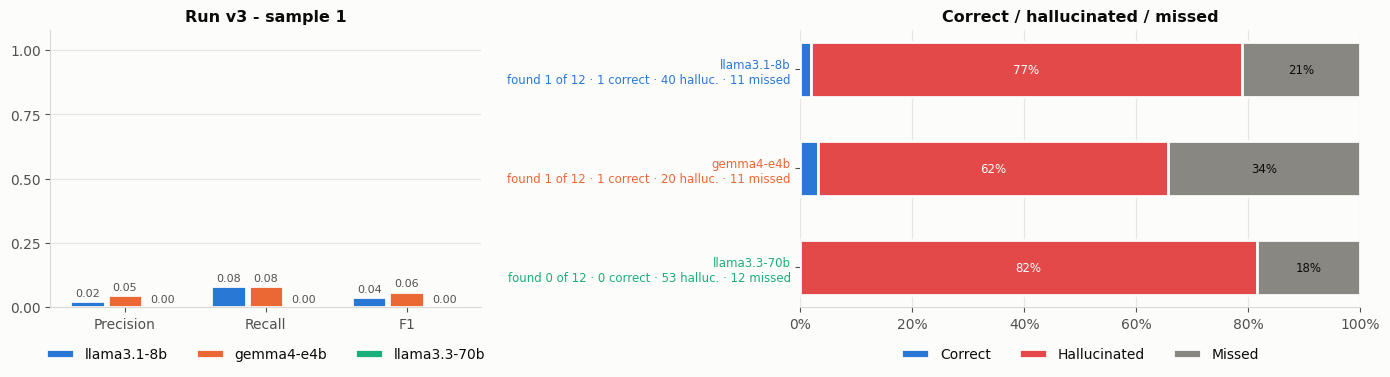

saved -> data\output\rda\runs\v3\evaluation_sample1.png


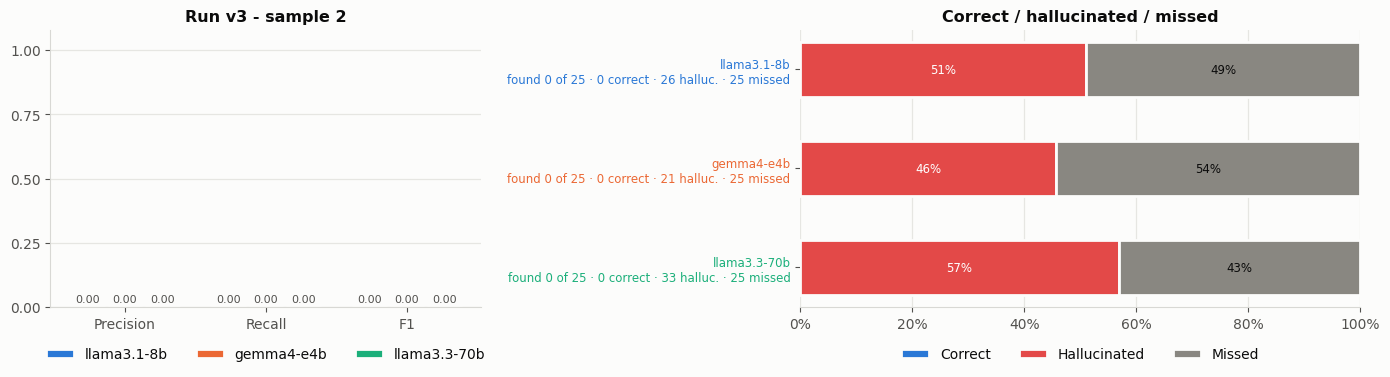

saved -> data\output\rda\runs\v3\evaluation_sample2.png


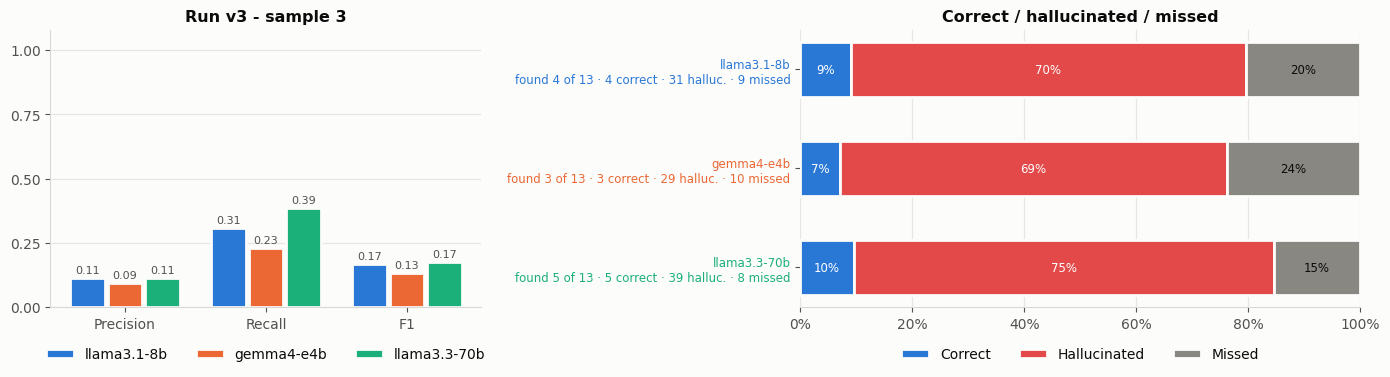

saved -> data\output\rda\runs\v3\evaluation_sample3.png


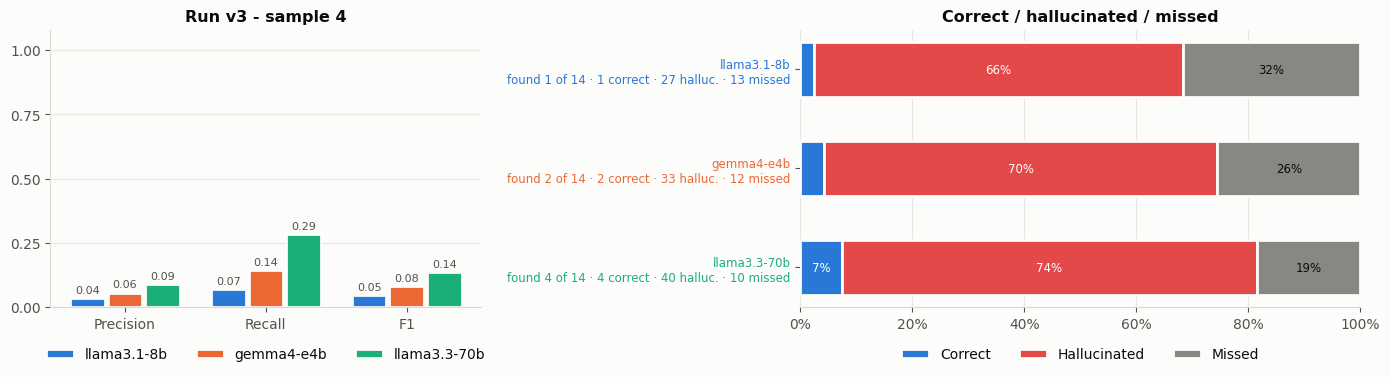

saved -> data\output\rda\runs\v3\evaluation_sample4.png


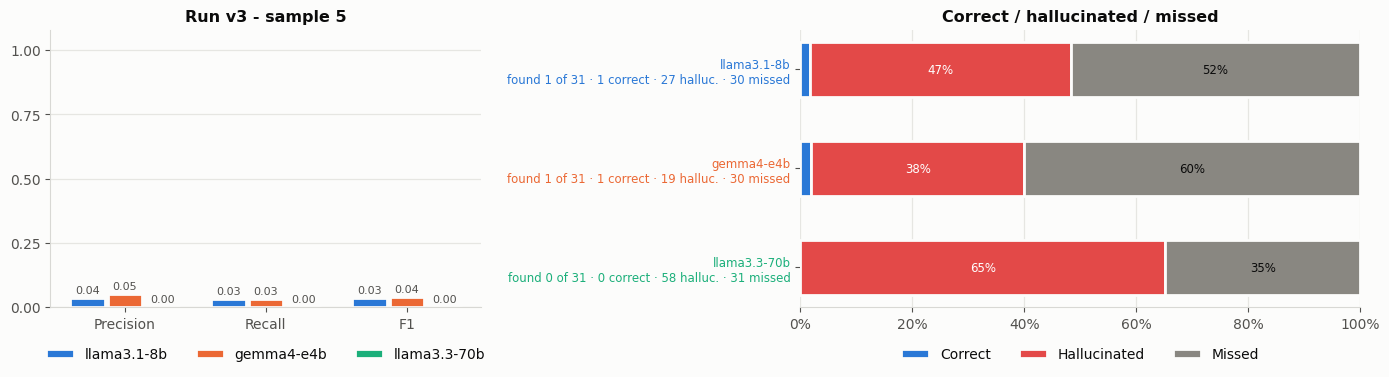

saved -> data\output\rda\runs\v3\evaluation_sample5.png


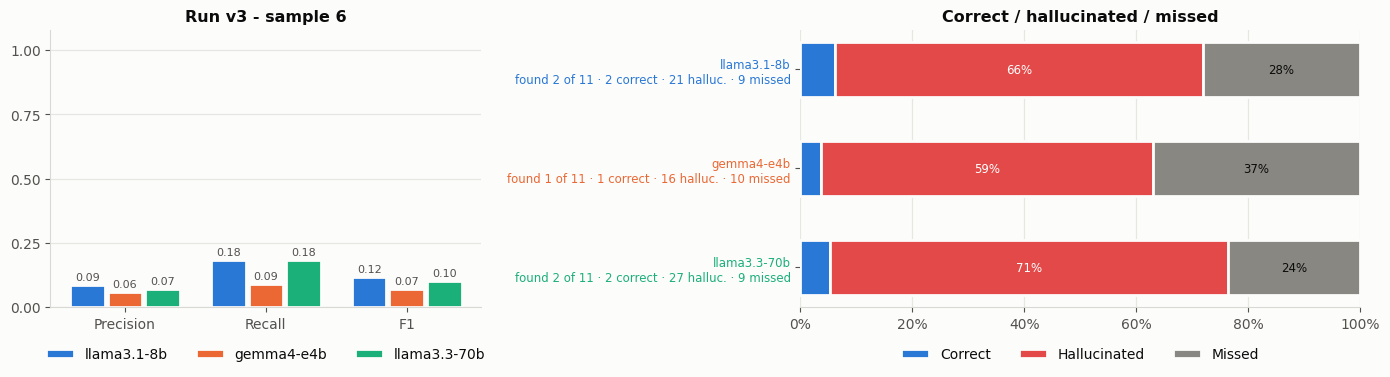

saved -> data\output\rda\runs\v3\evaluation_sample6.png


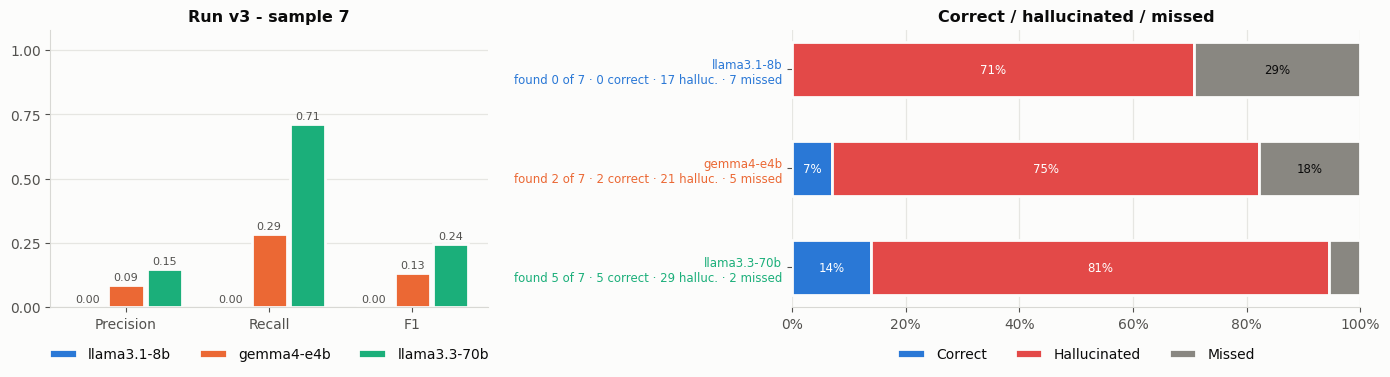

saved -> data\output\rda\runs\v3\evaluation_sample7.png


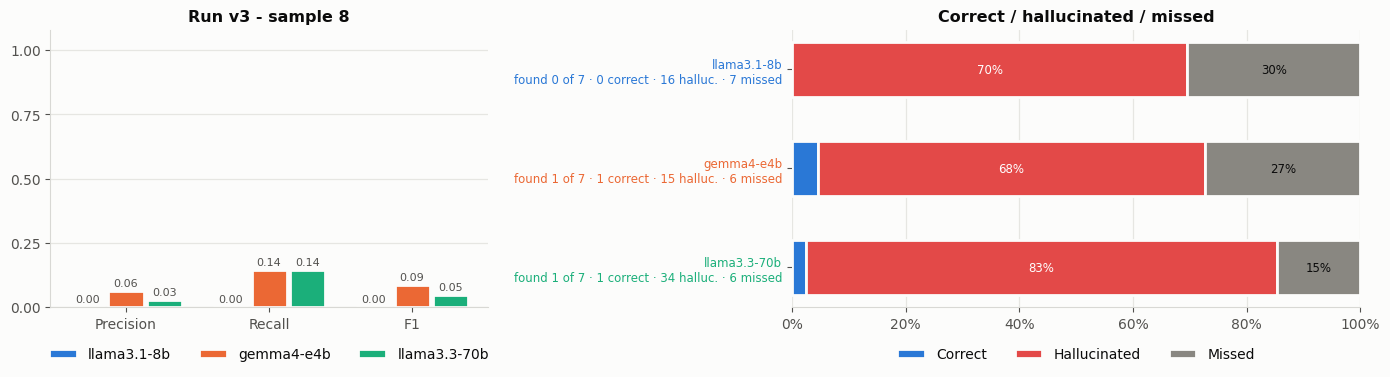

saved -> data\output\rda\runs\v3\evaluation_sample8.png


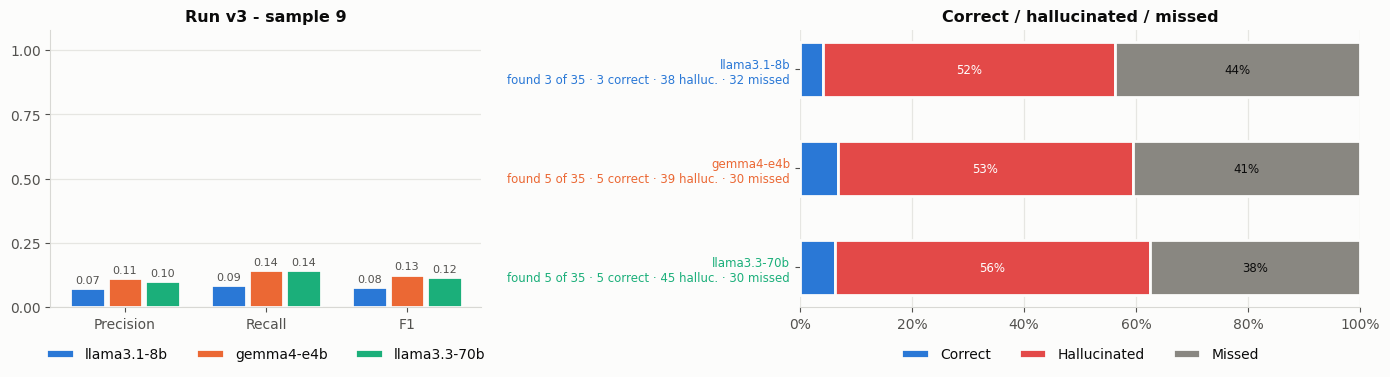

saved -> data\output\rda\runs\v3\evaluation_sample9.png


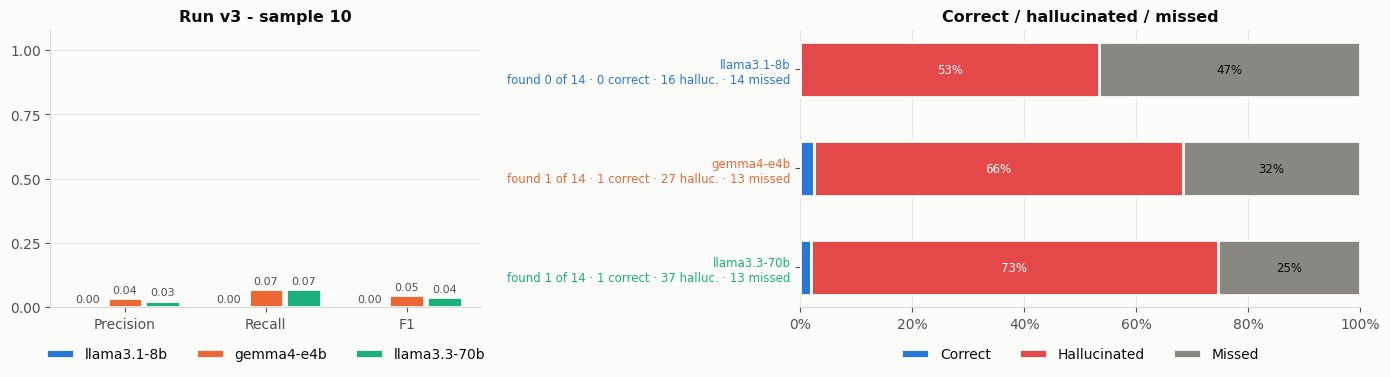

saved -> data\output\rda\runs\v3\evaluation_sample10.png


In [4]:
for s in samples[:-1]:
    plot_scores(table[table["sample"] == s], f"Run {RUN} - sample {s}", CHART.with_name(f"evaluation_sample{s}.png"))


## 4. In plain words


In [5]:
pooled_rows = table[table["sample"] == "All"].set_index("model")
print(f"Run {RUN}: {len(samples) - 1} sample(s) with a reference: {', '.join(samples[:-1])}.\n")
for m in models:
    r = pooled_rows.loc[m]
    print(f"{m}: found {int(r.found)} of {int(r['fields in reference'])} reference fields ({r.recall:.0%}), "
          f"wrote {int(r.correct + r.hallucinated)} fields of which {int(r.hallucinated)} were wrong or made up; "
          f"F1 {r.f1:.2f}.")
best = pooled_rows.f1.idxmax()
print(f"\nBest over all samples: {best} (F1 {pooled_rows.f1.max():.2f}).")
spread = table[table["sample"] != "All"].groupby("model").f1.agg(["min", "max"])
for m in models:
    print(f"{m}: F1 ranges from {spread.loc[m, 'min']:.2f} to {spread.loc[m, 'max']:.2f} across samples.")


Run v3: 10 sample(s) with a reference: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10.

llama3.1-8b: found 12 of 169 reference fields (7%), wrote 271 fields of which 259 were wrong or made up; F1 0.06.
gemma4-e4b: found 17 of 169 reference fields (10%), wrote 257 fields of which 240 were wrong or made up; F1 0.08.
llama3.3-70b: found 23 of 169 reference fields (14%), wrote 418 fields of which 395 were wrong or made up; F1 0.08.

Best over all samples: gemma4-e4b (F1 0.08).
llama3.1-8b: F1 ranges from 0.00 to 0.17 across samples.
gemma4-e4b: F1 ranges from 0.00 to 0.13 across samples.
llama3.3-70b: F1 ranges from 0.00 to 0.24 across samples.
